# Øvelser: klyngeanalyse

**Social Data Science 1: lektion 7**

Øvelserne bygger videre på PCA og k-means fra slides (*Del 6: PCA og k-means*) på det datasæt, vi
har preprocesseret sammen, `ft_lovforslag.csv`. I slides valgte vi seks klynger, fordi vi vidste,
at der var seks områder, og vi kiggede kun på én kørsel. Her stiller vi de spørgsmål, man skal
stille i en rigtig analyse:

1. Hvor mange klynger er der i data?
2. Hvad handler klyngerne om, og hvilke debatter passer ikke ind?
3. Finder klyngerne emner, eller finder de personer?

Under **Hjælp** står, hvor I har set de funktioner, I skal bruge:

- **Slides**: lektion 7-slides, med navnet på slidet.
- **Preprocess-notebooken**: `l7_preprocess_dkparl_trinvis`, med trinnets nummer.
- **spaCy-notebooken**: `l7_spacy_supplement`, med trinnets nummer.

---

## Opsætning

Kør cellen. Den indlæser data og definerer stopordslisten fra slides (*Fra tekst til tabel*).
Ret stien, så den peger på jeres egen kopi af `ft_lovforslag.csv`.

k-means kører mange gange i øvelserne. På hele materialet tager det nogle minutter.

In [2]:
import pandas as pd
import numpy as np
from plotnine import *


sti = "/Users/jeppefl/Library/CloudStorage/OneDrive-AalborgUniversitet/01_work/01_undervisning/02_sds1/01_slides/lektion-7/resources/ft_lovforslag.csv"
korpus = pd.read_csv(sti)

stopord = set("""og i jeg det at en den til er som på de med han af for ikke
der var mig sig men et har om vi min havde ham hun nu over da fra du ud sin dem
os op man hans hvor eller hvad skal selv her alle vil blev kunne ind når være dog
jo dette dig deres end mit også under have dens hvis dine disse hvem vores jer
sådan andre nogle bliver blive kan så ved mod meget rigtig tak hr fru ordfører
ordføreren forslag lovforslag lovforslaget minister ministeren værsgo altså godt
synes mener bare lige hele netop sige siger""".split())

print(korpus.shape)

(3070, 9)


---

## 1. Hvor mange klynger?

I slides valgte vi `k=6`, fordi vi vidste, at der var seks områder (*k-means: find grupperne*). I en
rigtig analyse ved man det ikke. To almindelige mål kan hjælpe:

- **Inertia**: den samlede afstand fra debatterne til deres klyngecenter. Den falder altid, når `k`
  stiger. Man leder efter et *knæk*, hvor den holder op med at falde meget.
- **Silhouette**: hvor tæt hver debat ligger på sin egen klynge sammenlignet med den nærmeste anden.
  Går fra −1 til 1. Høj er godt, omkring 0 betyder, at klyngerne overlapper.

- **ARI** (*adjusted Rand index*): hvor godt klyngerne passer med politikområderne, korrigeret for
  tilfældighed. 1 er perfekt, 0 er som tilfældigt. Den kan kun bruges, fordi vi har en facitliste.

**Opgave:**

1. Lav TF-IDF-tabellen fra slides for de seks navngivne områder, med stopord fjernet og `min_df=20`.
   Skriv DTM- og TF-IDF-delen som en funktion `lav_tfidf(o, min_df)`, så den kan genbruges i øvelse 3.
2. Kør k-means for `k` fra 2 til 10. Gem inertia, silhouette og ARI for hver.
3. Tegn de tre mål mod `k`.

**Hjælp:**

- Slides, *Fra tekst til tabel*, *Document-term matrix* og *TF-IDF*: hele opskriften.
- `KMeans(...).fit(tfidf)` giver `km.inertia_` og `km.labels_`.
- `from sklearn.metrics import adjusted_rand_score` og `adjusted_rand_score(omraade, km.labels_)`.
- `from sklearn.metrics import silhouette_score` og `silhouette_score(tfidf, km.labels_)`.
- spaCy-notebooken, trin 4: en tabel, der fyldes én række ad gangen med `.loc[len(...)]`.
- Slides, *Tegn det*: `.melt()` og plotnine med `facet_wrap("~maal", scales="free_y")`.

In [3]:
# Din kode her
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

tek = korpus[korpus["omraade"] != "Andet"].copy()

o = (tek["tekst"].str.lower()
     .str.replace(r"[^a-zæøå ]", " ", regex=True)
     .str.split().explode())
o = o[(o.str.len() > 2) & ~o.isin(stopord)]

In [4]:
def lav_tfidf(o, min_df):
    df = o.rename("ord").reset_index().drop_duplicates()["ord"].value_counts()
    behold = df[(df >= min_df) & (df <= 0.5 * len(tek))].index
    o = o[o.isin(behold)]
    dtm = pd.crosstab(o.index, o)

    tf = dtm.div(dtm.sum(axis=1), axis=0)
    idf = np.log(len(dtm) / (dtm > 0).sum())
    tfidf = tf * idf
    return tfidf.div(np.sqrt((tfidf ** 2).sum(axis=1)), axis=0)

tfidf = lav_tfidf(o, 20)
omraade = tek.loc[tfidf.index, "omraade"]

print(tfidf.shape)

(1828, 10668)


In [5]:
valg_k = pd.DataFrame(columns=["k", "inertia", "silhouette", "ARI"])

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(tfidf)
    valg_k.loc[len(valg_k)] = [k, km.inertia_,
                               silhouette_score(tfidf, km.labels_),
                               adjusted_rand_score(omraade, km.labels_)]

print(valg_k.round(3))

      k   inertia  silhouette    ARI
0   2.0  1742.441       0.011  0.089
1   3.0  1724.296       0.015  0.292
2   4.0  1709.864       0.017  0.449
3   5.0  1688.623       0.022  0.511
4   6.0  1676.121       0.024  0.646
5   7.0  1664.107       0.025  0.540
6   8.0  1655.478       0.027  0.607
7   9.0  1635.404       0.032  0.562
8  10.0  1626.658       0.034  0.493


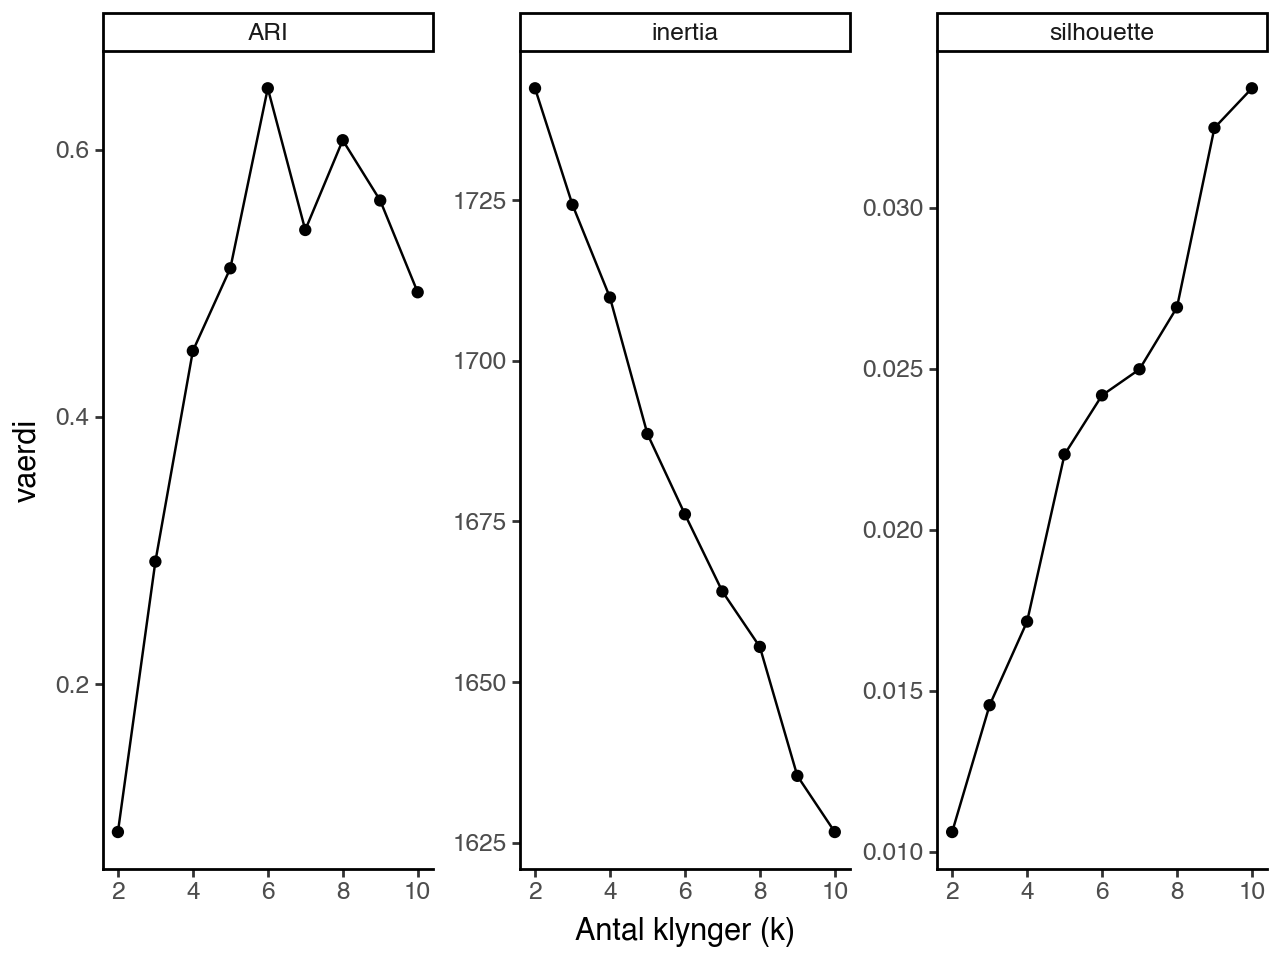

In [7]:
til_figur = valg_k.melt(id_vars="k", var_name="maal", value_name="vaerdi")

(ggplot(til_figur, aes(x="k", y="vaerdi"))
 + geom_line()
 + geom_point()
 + facet_wrap("~maal", scales="free_y")
 + labs(x="Antal klynger (k)", y=None)
 + theme_classic())

**Kig efter i viewer:** Åbn `valg_k`. Hvor er silhouette højest? Hvor er ARI højest? Er det det samme `k`?

**Til diskussion:**

- Er der et tydeligt knæk i inertia? Peger silhouette på et bestemt `k`?
- Hvad betyder en silhouette tæt på 0 for, hvordan debatterne ligger i forhold til hinanden?
- Hvis I ikke havde facitlisten, hvilket `k` ville I så vælge? Og hvordan ville I begrunde det?

*Jeres svar:*